**objective**: test the numerically modelled conductive heat flow in PyBasin against an analytical solution

The analytical solution for a step change in temperature at the boundary ($x=0$) of a semi infinite homogeneous medium is given by:

$$\Delta T (x, t) = \Delta T_0 \; \mathrm{erfc} \left(\dfrac{x}{2 \sqrt{\kappa t}} \right)$$

where $\Delta T$ is the change in temperature, $\kappa$ is the thermal diffusivity, $\Delta T_0$ is the change in temperature at the boundary and $\mathrm{erfc}$ is the complementary error function (Carslaw and Jaeger, 1959; see also Bruggeman, 1999).

The thermal diffusivity is defined as $\kappa = K / (\rho c)$, with $K$ the thermal conductivity, $\rho$ the density and $c$ the heat capacity.

Using this solution the distance over which the change in temperature is 50% of the change of the input signal (i.e. $\Delta T = 0.5 \, \Delta T_0$) can be derived as:

$$x = 2 \; \mathrm{erf}^{-1}(0.5) \sqrt{\kappa t}$$

## Import modules

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as pl
from scipy.special import erfc, erfinv

# add the repository root to the path so the model library can be imported
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from lib import pybasin_lib

--------------------
No module named 'lib.calculate_reduced_AFT_lengths'
failed to import fortran annealing module
use slower python implementation of AFT annealing module instead
compile the fortran module by running the following command in the source directory of this module:
f2py -c calculate_reduced_AFT_lengths.f90 -m calculate_reduced_AFT_lengths
--------------------
------------------------------
use slower python implementation of AFT annealing module instead
compile the fortran module by running the following command in the source directory of this module:
f2py -c calculate_reduced_AFT_lengths.f90 -m calculate_reduced_AFT_lengths
------------------------------


## Set up the model parameters

In [2]:
# seconds per year
yr = 365.25 * 24 * 3600.0

# thermal diffusivity (m2 s-1)
kappa = 1.5e-6

# thermal parameters consistent with the chosen diffusivity
# the diffusivity equals K / (rho c)
K_value = 2.5
rho_value = 2500.0
c_value = K_value / (kappa * rho_value)

# imposed temperature change at the boundary (degrees C)
dT0 = 100.0

# model domain, chosen large enough that the far boundary is not reached
L = 40000.0
dz = 100.0
z = np.arange(0.0, L + dz, dz)
n_nodes = len(z)

# thermal conductivity is used as a scalar in the solver
# the remaining properties are specified per node
K = K_value
rho = np.ones(n_nodes) * rho_value
c = np.ones(n_nodes) * c_value
Q = np.zeros(n_nodes)

# time stepping
dt = 2000.0 * yr
total_time = 2.0e6 * yr
n_steps = int(round(total_time / dt))

# times at which to compare the numerical and analytical solutions (My)
output_times_my = [0.5, 1.0, 2.0]
output_steps = [int(round(t_my * 1e6 * yr / dt)) for t_my in output_times_my]

## Run the PyBasin numerical heat flow model

In [3]:
# initial temperature field, zero everywhere
T = np.zeros(n_nodes)

# boundary conditions, fixed temperature at the top (the step change)
# and a fixed far field temperature at the base
fixed_upper_temperature = dT0
fixed_lower_temperature = 0.0
T[0] = dT0

# reuse the system matrix because the grid and properties are constant
A = None
numerical_profiles = {}

# march the implicit finite difference solver forward in time
for step in range(1, n_steps + 1):
    T, A = pybasin_lib.solve_1D_heat_flow(
        T, z, dt, K, rho, c, Q,
        upper_bnd_flux=None,
        lower_bnd_flux=None,
        fixed_upper_temperature=fixed_upper_temperature,
        fixed_lower_temperature=fixed_lower_temperature,
        A=A)

    if step in output_steps:
        numerical_profiles[step] = T.copy()

## Compare the numerical and analytical solutions

maximum absolute difference numerical vs analytical: 0.3650 degrees C


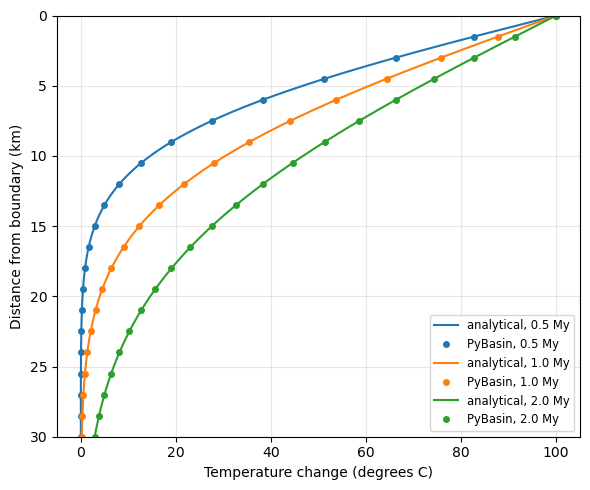

In [4]:
fig, ax = pl.subplots(1, 1, figsize=(6, 5))

colors = ['C0', 'C1', 'C2']

max_error = 0.0

for t_my, step, color in zip(output_times_my, output_steps, colors):
    t_seconds = step * dt

    # analytical solution
    analytical = dT0 * erfc(z / (2.0 * np.sqrt(kappa * t_seconds)))

    # numerical solution
    numerical = numerical_profiles[step]

    # keep track of the largest difference between both solutions
    max_error = max(max_error, np.max(np.abs(numerical - analytical)))

    ax.plot(analytical, z / 1000.0, color=color, lw=1.5,
            label='analytical, %0.1f My' % t_my)
    ax.plot(numerical, z / 1000.0, color=color, lw=0, marker='o',
            markersize=4, markevery=15,
            label='PyBasin, %0.1f My' % t_my)

ax.set_ylim(0, 30)
ax.invert_yaxis()
ax.set_xlabel('Temperature change (degrees C)')
ax.set_ylabel('Distance from boundary (km)')
ax.legend(fontsize='small', loc='lower right')
ax.grid(True, alpha=0.3)

fig.tight_layout()

print('maximum absolute difference numerical vs analytical: '
      '%0.4f degrees C' % max_error)

## Characteristic length scale of conductive heat flow

As an additional check the analytical solution is used to calculate the distance over which the temperature change reaches 50% of the imposed boundary change, and the thermal diffusion length, both as a function of time.

thermal diffusion length after 2.0 My: 19460.0 m


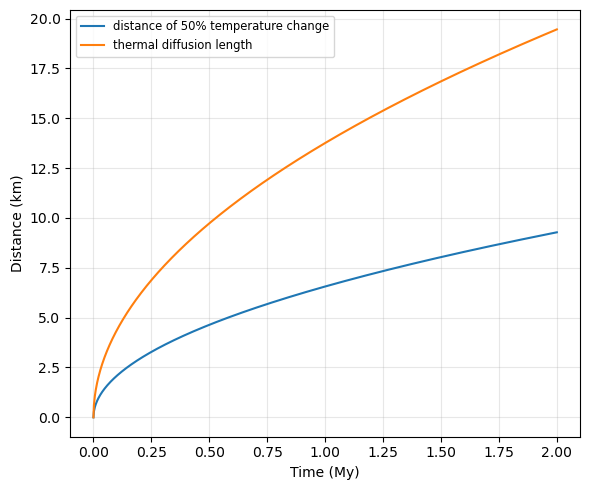

In [5]:
t = np.linspace(0, 2, 1001) * 1e6 * yr

# distance of the 50 percent temperature change
x_half = 2 * erfinv(0.5) * np.sqrt(kappa * t)

# thermal diffusion length
diffusion_length = 2 * np.sqrt(kappa * t)

fig, ax = pl.subplots(1, 1, figsize=(6, 5))

ax.plot(t / (1e6 * yr), x_half / 1000.0,
        label='distance of 50% temperature change')
ax.plot(t / (1e6 * yr), diffusion_length / 1000.0,
        label='thermal diffusion length')

ax.set_xlabel('Time (My)')
ax.set_ylabel('Distance (km)')
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)

fig.tight_layout()

print('thermal diffusion length after %0.1f My: %0.1f m'
      % (t[-1] / (1e6 * yr), diffusion_length[-1]))